In [1]:
#pip install --upgrade --force-reinstall  git+https://github.com/kanawa12/symcontroltools

In [ ]:
#pip install git+https://github.com/kanawa12/symcontroltools
#https://github.com/kanawa12/symcontroltools

import numpy as np
import sympy as sp
import scipy as sc
import control as ct
import symcontroltools as sct
from symcontroltools import dp
import os
import knw_symtools as ks
# simudict : simulinkで使うパラメータ集
# masterdict : 
# symboldict : 各シンボルに数値(スカラー)を対応させた辞書


In [ ]:

def makepairdict(keymat, valmat):
        pdict = {}
        rows, cols = valmat.shape
        for i in range(rows):
            for j in range(cols):
                pdict[keymat[i, j]] = valmat[i, j]
        return pdict

def makePDict(keylist, smatdict):
    """
    シンボル行列とパラメータ行列のタプルの辞書のうち、keylistで指定されたものについてシンボルとパラメータの組の辞書を作成
    """
    pdict = {}
    for key in keylist:
        pdict = pdict | makepairdict(smatdict[key[0]][0], smatdict[key[0]][key[1]])
    return pdict


def parse23(mats):
    Aa = np.zeros((3,3))
    Bb = np.zeros((3,1))
    Cc = np.zeros((1,3))
    print(Aa)
    for i in range(2):
        for j in range(2):
            Aa[i,j] = mats[0][i,j]
        Bb[i, 0] = mats[1][i, 0]
        Cc[0, i] = mats[2][0, i]
    return (Aa, Bb, Cc, mats[3])

#def wmd(key, val):

def simud(key, val = None):
    """
    simudict(simulink)用
    """
    if val == None:
        return simudict[key]
    else:
        simudict[key] = val

def mtrd(key, val = None):
    """
    maindict(メインの辞書)用
    """
    if val == None:
        return maindict[key]
    else:
        maindict[key] = val


In [4]:
pdim = 2
dims = np.array([pdim, pdim], dtype=np.int8) # plant, ref #!!!
simudictbase = {
"p_dim": dims[0], "r_dim": dims[1],

# 適応ゲイン初期値
"K0_e": 0, "K0_x": np.array([]), "K0_u": 0,
# その他初期値
"sig_e": 0, "sig_u" : 0,
"kpg_e": 0, "kpg_u" : 0,
"P0": 1000*np.eye(4), "theta0" : np.zeros([4,1]), "lambda": 0.98,
"Ts": 0.01, "T_end": 50
}

simudict_1d = {
"Ge": 1e5, "Gu": 1e5, "Gx": 1e5,
"sig_x" : np.diag([ 0]), "kpg_x" : 0.00*np.diag([ 1]),
"sigset" : [(3, 1, 0), (5, 1, 0)]
}

simudict_2d = {
"Ge": 1e1, "Gu": 1e1,
"Gx": 100*np.diag([10, 10]),#np.array((1e4)*np.identity(dims[1])),
"sig_x" : np.diag([0, 0]), "kpg_x" : 0.00*np.diag([0, 1]),
"sigset": [(0.01, 1, 0),(5, 1, 2), (50, 5, 4), (100, 10, 5)]
}

simudict_3d = {
"Ge": 1e3, "Gu": 1e3,
"Gx": 1000*np.diag([10, 10, 10]),#np.array((1e4)*np.identity(dims[1])),
"sig_x" : 0.0*np.diag([ 1,1,1]), "kpg_x" : 0.00*np.diag([ 0,0,0]),
"sigset": [(0.1, 1, 0),(1, 1, 1),(5, 1, 2), (20, 1, 3), (50, 5, 4), (100, 10, 5)]
#sigset = [ (400, 20, 0), (10, 15, 0), (80, 15, 0), (370, 10, 0), (300, 10, 0), (5000, 10, 0), (7000, 10, 0), (1000, 10, 0), (10000, 10, 0), (12000, 10, 0)]
}
"""(0.01, 1, 8), (0.1, 1, 4),"""

'(0.01, 1, 8), (0.1, 1, 4),'

In [5]:
simudicts = {1: simudict_1d, 2: simudict_2d, 3:simudict_3d}
simudict = simudictbase | simudicts[dims[0]]
sigset = simudict["sigset"]
simudict["sigfreq"]= [i[0] for i in sigset]
simudict["sigamp"] = [i[1] for i in sigset]
simudict["sigphs"]=  [i[2] for i in sigset]
simudict["signormcoef"] = 1*1/np.sum(np.array(simudict["sigamp"]))

In [6]:
p1p1obs = r"Dict(Tuple(Symbol('Am'), Tuple(ImmutableDenseMatrix([[Symbol('{a_m}_{11}')]]), ImmutableDenseMatrix([[Symbol('{a_m}_{11}')]]))), Tuple(Symbol('Ap'), Tuple(ImmutableDenseMatrix([[Symbol('{a_p}_{11}')]]), ImmutableDenseMatrix([[Symbol('{a_p}_{11}')]]))), Tuple(Symbol('Bm'), Tuple(ImmutableDenseMatrix([[Symbol('{b_m}_{11}')]]), ImmutableDenseMatrix([[Symbol('{b_m}_{11}')]]))), Tuple(Symbol('Bp'), Tuple(ImmutableDenseMatrix([[Symbol('{b_p}_{11}')]]), ImmutableDenseMatrix([[Symbol('{b_p}_{11}')]]))), Tuple(Symbol('Cm'), Tuple(ImmutableDenseMatrix([[Symbol('{c_m}_{11}')]]), ImmutableDenseMatrix([[Integer(1)]]))), Tuple(Symbol('Cp'), Tuple(ImmutableDenseMatrix([[Symbol('{c_p}_{11}')]]), ImmutableDenseMatrix([[Integer(1)]]))), Tuple(Symbol('Dm'), Tuple(ImmutableDenseMatrix([[Symbol('{d_m}_{11}')]]), ImmutableDenseMatrix([[Integer(0)]]))), Tuple(Symbol('Dp'), Tuple(ImmutableDenseMatrix([[Symbol('{d_p}_{11}')]]), ImmutableDenseMatrix([[Integer(0)]]))), Tuple(Symbol('kxku'), Tuple(ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_u}_{11}')]]))), Tuple(Symbol('kxkut'), Tuple(ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_u}_{11}')]]))), Tuple(Symbol('cgteqs'), Tuple(ImmutableDenseMatrix([[Add(Mul(Integer(-1), Symbol('{a_m}_{11}')), Symbol('{a_p}_{11}'), Mul(Symbol('{b_p}_{11}'), Symbol('{k_x}_{11}')))], [Add(Mul(Integer(-1), Symbol('{b_m}_{11}')), Mul(Symbol('{b_p}_{11}'), Symbol('{k_u}_{11}')))]]))), Tuple(Symbol('estans'), Tuple(ImmutableDenseMatrix([[Integer(1), Symbol('{k_x}_{11}')], [Integer(0), Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Symbol('{a_p}_{11}')], [Symbol('{b_p}_{11}')]]), ImmutableDenseMatrix([[Symbol('{a_m}_{11}')], [Symbol('{b_m}_{11}')]]))), Tuple(Symbol('cgtans'), Tuple(ImmutableDenseMatrix([[Symbol('{b_p}_{11}'), Integer(0)], [Integer(0), Symbol('{b_p}_{11}')]]), ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Add(Symbol('{a_m}_{11}'), Mul(Integer(-1), Symbol('{a_p}_{11}')))], [Symbol('{b_m}_{11}')]]))), Tuple(Symbol('KAS'), Tuple(ImmutableDenseMatrix([[Symbol('{a_p}_{11}'), Symbol('{b_p}_{11}')], [Integer(1), Integer(0)]]), ImmutableDenseMatrix([[Symbol('{s_a}_{11}'), Symbol('{s_b}_{11}')], [Symbol('{k_x}_{11}'), Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Mul(Symbol('{a_m}_{11}'), Symbol('{s_a}_{11}')), Mul(Symbol('{b_m}_{11}'), Symbol('{s_a}_{11}'))], [Integer(1), Integer(0)]]))))"
p2r2obs = r"Dict(Tuple(Symbol('Dm'), Tuple(ImmutableDenseMatrix([[Symbol('{d_m}_{11}')]]), ImmutableDenseMatrix([[Integer(0)]]))), Tuple(Symbol('Dp'), Tuple(ImmutableDenseMatrix([[Symbol('{d_p}_{11}')]]), ImmutableDenseMatrix([[Integer(0)]]))), Tuple(Symbol('Bm'), Tuple(ImmutableDenseMatrix([[Symbol('{b_m}_{11}')], [Symbol('{b_m}_{21}')]]), ImmutableDenseMatrix([[Symbol('{b_m}_{11}')], [Symbol('{b_m}_{21}')]]))), Tuple(Symbol('Bp'), Tuple(ImmutableDenseMatrix([[Symbol('{b_p}_{11}')], [Symbol('{b_p}_{21}')]]), ImmutableDenseMatrix([[Symbol('{b_p}_{11}')], [Symbol('{b_p}_{21}')]]))), Tuple(Symbol('Cm'), Tuple(ImmutableDenseMatrix([[Symbol('{c_m}_{11}'), Symbol('{c_m}_{12}')]]), ImmutableDenseMatrix([[Integer(0), Integer(1)]]))), Tuple(Symbol('Cp'), Tuple(ImmutableDenseMatrix([[Symbol('{c_p}_{11}'), Symbol('{c_p}_{12}')]]), ImmutableDenseMatrix([[Integer(0), Integer(1)]]))), Tuple(Symbol('kxku'), Tuple(ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_x}_{12}')], [Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_x}_{12}')], [Symbol('{k_u}_{11}')]]))), Tuple(Symbol('kxkut'), Tuple(ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_x}_{12}')], [Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_x}_{12}')], [Symbol('{k_u}_{11}')]]))), Tuple(Symbol('Am'), Tuple(ImmutableDenseMatrix([[Symbol('{a_m}_{11}'), Symbol('{a_m}_{12}')], [Symbol('{a_m}_{21}'), Symbol('{a_m}_{22}')]]), ImmutableDenseMatrix([[Integer(0), Symbol('{a_m}_{12}')], [Integer(1), Symbol('{a_m}_{22}')]]))), Tuple(Symbol('Ap'), Tuple(ImmutableDenseMatrix([[Symbol('{a_p}_{11}'), Symbol('{a_p}_{12}')], [Symbol('{a_p}_{21}'), Symbol('{a_p}_{22}')]]), ImmutableDenseMatrix([[Integer(0), Symbol('{a_p}_{12}')], [Integer(1), Symbol('{a_p}_{22}')]]))), Tuple(Symbol('estans'), Tuple(ImmutableDenseMatrix([[Integer(1), Integer(0), Add(Mul(Integer(-1), Symbol('{a_m}_{22}'), Symbol('{k_x}_{11}')), Symbol('{k_x}_{12}')), Mul(Symbol('{a_m}_{12}'), Symbol('{k_x}_{11}'))], [Integer(0), Integer(1), Symbol('{k_x}_{11}'), Symbol('{k_x}_{12}')], [Integer(0), Integer(0), Add(Mul(Integer(-1), Symbol('{b_m}_{21}'), Symbol('{k_x}_{11}')), Symbol('{k_u}_{11}')), Mul(Symbol('{b_m}_{11}'), Symbol('{k_x}_{11}'))]]), ImmutableDenseMatrix([[Symbol('{a_p}_{12}')], [Symbol('{a_p}_{22}')], [Symbol('{b_p}_{11}')], [Symbol('{b_p}_{21}')]]), ImmutableDenseMatrix([[Symbol('{a_m}_{12}')], [Symbol('{a_m}_{22}')], [Symbol('{b_m}_{11}')]]))), Tuple(Symbol('cgteqs'), Tuple(ImmutableDenseMatrix([[Add(Mul(Symbol('{a_m}_{12}'), Symbol('{b_p}_{21}'), Symbol('{k_x}_{11}')), Mul(Integer(-1), Symbol('{a_m}_{12}')), Symbol('{a_p}_{12}'), Mul(Symbol('{b_p}_{11}'), Add(Mul(Integer(-1), Symbol('{a_m}_{22}'), Symbol('{k_x}_{11}')), Symbol('{k_x}_{12}'))))], [Add(Mul(Integer(-1), Symbol('{a_m}_{22}')), Symbol('{a_p}_{22}'), Mul(Symbol('{b_p}_{11}'), Symbol('{k_x}_{11}')), Mul(Symbol('{b_p}_{21}'), Symbol('{k_x}_{12}')))], [Add(Mul(Symbol('{b_m}_{11}'), Symbol('{b_p}_{21}'), Symbol('{k_x}_{11}')), Mul(Integer(-1), Symbol('{b_m}_{11}')), Mul(Symbol('{b_p}_{11}'), Add(Mul(Integer(-1), Symbol('{b_m}_{21}'), Symbol('{k_x}_{11}')), Symbol('{k_u}_{11}'))))]]))), Tuple(Symbol('cgtans'), Tuple(ImmutableDenseMatrix([[Add(Mul(Symbol('{a_m}_{12}'), Symbol('{b_p}_{21}')), Mul(Integer(-1), Symbol('{a_m}_{22}'), Symbol('{b_p}_{11}'))), Symbol('{b_p}_{11}'), Integer(0)], [Symbol('{b_p}_{11}'), Symbol('{b_p}_{21}'), Integer(0)], [Add(Mul(Symbol('{b_m}_{11}'), Symbol('{b_p}_{21}')), Mul(Integer(-1), Symbol('{b_m}_{21}'), Symbol('{b_p}_{11}'))), Integer(0), Symbol('{b_p}_{11}')]]), ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_x}_{12}')], [Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Add(Symbol('{a_m}_{12}'), Mul(Integer(-1), Symbol('{a_p}_{12}')))], [Add(Symbol('{a_m}_{22}'), Mul(Integer(-1), Symbol('{a_p}_{22}')))], [Symbol('{b_m}_{11}')]]))), Tuple(Symbol('KAS'), Tuple(ImmutableDenseMatrix([[Integer(0), Symbol('{a_p}_{12}'), Symbol('{b_p}_{11}')], [Integer(1), Symbol('{a_p}_{22}'), Symbol('{b_p}_{21}')], [Integer(0), Integer(1), Integer(0)]]), ImmutableDenseMatrix([[Symbol('{s_a}_{11}'), Symbol('{s_a}_{12}'), Symbol('{s_b}_{11}')], [Symbol('{s_a}_{21}'), Symbol('{s_a}_{22}'), Symbol('{s_b}_{21}')], [Symbol('{k_x}_{11}'), Symbol('{k_x}_{12}'), Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Symbol('{s_a}_{12}'), Add(Mul(Symbol('{a_m}_{12}'), Symbol('{s_a}_{11}')), Mul(Symbol('{a_m}_{22}'), Symbol('{s_a}_{12}'))), Add(Mul(Symbol('{b_m}_{11}'), Symbol('{s_a}_{11}')), Mul(Symbol('{b_m}_{21}'), Symbol('{s_a}_{12}')))], [Symbol('{s_a}_{22}'), Add(Mul(Symbol('{a_m}_{12}'), Symbol('{s_a}_{21}')), Mul(Symbol('{a_m}_{22}'), Symbol('{s_a}_{22}'))), Add(Mul(Symbol('{b_m}_{11}'), Symbol('{s_a}_{21}')), Mul(Symbol('{b_m}_{21}'), Symbol('{s_a}_{22}')))], [Integer(0), Integer(1), Integer(0)]]))))"
p3r3obs = r"Dict(Tuple(Symbol('Dm'), Tuple(ImmutableDenseMatrix([[Symbol('{d_m}_{11}')]]), ImmutableDenseMatrix([[Integer(0)]]))), Tuple(Symbol('Dp'), Tuple(ImmutableDenseMatrix([[Symbol('{d_p}_{11}')]]), ImmutableDenseMatrix([[Integer(0)]]))), Tuple(Symbol('Bm'), Tuple(ImmutableDenseMatrix([[Symbol('{b_m}_{11}')], [Symbol('{b_m}_{21}')], [Symbol('{b_m}_{31}')]]), ImmutableDenseMatrix([[Symbol('{b_m}_{11}')], [Symbol('{b_m}_{21}')], [Symbol('{b_m}_{31}')]]))), Tuple(Symbol('Bp'), Tuple(ImmutableDenseMatrix([[Symbol('{b_p}_{11}')], [Symbol('{b_p}_{21}')], [Symbol('{b_p}_{31}')]]), ImmutableDenseMatrix([[Symbol('{b_p}_{11}')], [Symbol('{b_p}_{21}')], [Symbol('{b_p}_{31}')]]))), Tuple(Symbol('Cm'), Tuple(ImmutableDenseMatrix([[Symbol('{c_m}_{11}'), Symbol('{c_m}_{12}'), Symbol('{c_m}_{13}')]]), ImmutableDenseMatrix([[Integer(0), Integer(0), Integer(1)]]))), Tuple(Symbol('Cp'), Tuple(ImmutableDenseMatrix([[Symbol('{c_p}_{11}'), Symbol('{c_p}_{12}'), Symbol('{c_p}_{13}')]]), ImmutableDenseMatrix([[Integer(0), Integer(0), Integer(1)]]))), Tuple(Symbol('kxku'), Tuple(ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_x}_{12}')], [Symbol('{k_x}_{13}')], [Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_x}_{12}')], [Symbol('{k_x}_{13}')], [Symbol('{k_u}_{11}')]]))), Tuple(Symbol('kxkut'), Tuple(ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_x}_{12}')], [Symbol('{k_x}_{13}')], [Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_x}_{12}')], [Symbol('{k_x}_{13}')], [Symbol('{k_u}_{11}')]]))), Tuple(Symbol('Am'), Tuple(ImmutableDenseMatrix([[Symbol('{a_m}_{11}'), Symbol('{a_m}_{12}'), Symbol('{a_m}_{13}')], [Symbol('{a_m}_{21}'), Symbol('{a_m}_{22}'), Symbol('{a_m}_{23}')], [Symbol('{a_m}_{31}'), Symbol('{a_m}_{32}'), Symbol('{a_m}_{33}')]]), ImmutableDenseMatrix([[Integer(0), Integer(0), Symbol('{a_m}_{13}')], [Integer(1), Integer(0), Symbol('{a_m}_{23}')], [Integer(0), Integer(1), Symbol('{a_m}_{33}')]]))), Tuple(Symbol('Ap'), Tuple(ImmutableDenseMatrix([[Symbol('{a_p}_{11}'), Symbol('{a_p}_{12}'), Symbol('{a_p}_{13}')], [Symbol('{a_p}_{21}'), Symbol('{a_p}_{22}'), Symbol('{a_p}_{23}')], [Symbol('{a_p}_{31}'), Symbol('{a_p}_{32}'), Symbol('{a_p}_{33}')]]), ImmutableDenseMatrix([[Integer(0), Integer(0), Symbol('{a_p}_{13}')], [Integer(1), Integer(0), Symbol('{a_p}_{23}')], [Integer(0), Integer(1), Symbol('{a_p}_{33}')]]))), Tuple(Symbol('estans'), Tuple(ImmutableDenseMatrix([[Integer(1), Integer(0), Integer(0), Add(Mul(Integer(-1), Symbol('{a_m}_{23}'), Symbol('{k_x}_{11}')), Mul(Integer(-1), Symbol('{a_m}_{33}'), Symbol('{k_x}_{12}')), Symbol('{k_x}_{13}')), Mul(Symbol('{a_m}_{13}'), Symbol('{k_x}_{11}')), Mul(Symbol('{a_m}_{13}'), Symbol('{k_x}_{12}'))], [Integer(0), Integer(1), Integer(0), Add(Mul(Integer(-1), Symbol('{a_m}_{33}'), Symbol('{k_x}_{11}')), Symbol('{k_x}_{12}')), Add(Mul(Integer(-1), Symbol('{a_m}_{33}'), Symbol('{k_x}_{12}')), Symbol('{k_x}_{13}')), Add(Mul(Symbol('{a_m}_{13}'), Symbol('{k_x}_{11}')), Mul(Symbol('{a_m}_{23}'), Symbol('{k_x}_{12}')))], [Integer(0), Integer(0), Integer(1), Symbol('{k_x}_{11}'), Symbol('{k_x}_{12}'), Symbol('{k_x}_{13}')], [Integer(0), Integer(0), Integer(0), Add(Mul(Integer(-1), Symbol('{b_m}_{21}'), Symbol('{k_x}_{11}')), Mul(Integer(-1), Symbol('{b_m}_{31}'), Symbol('{k_x}_{12}')), Symbol('{k_u}_{11}')), Mul(Symbol('{b_m}_{11}'), Symbol('{k_x}_{11}')), Mul(Symbol('{b_m}_{11}'), Symbol('{k_x}_{12}'))]]), ImmutableDenseMatrix([[Symbol('{a_p}_{13}')], [Symbol('{a_p}_{23}')], [Symbol('{a_p}_{33}')], [Symbol('{b_p}_{11}')], [Symbol('{b_p}_{21}')], [Symbol('{b_p}_{31}')]]), ImmutableDenseMatrix([[Symbol('{a_m}_{13}')], [Symbol('{a_m}_{23}')], [Symbol('{a_m}_{33}')], [Symbol('{b_m}_{11}')]]))), Tuple(Symbol('cgtans'), Tuple(ImmutableDenseMatrix([[Add(Mul(Symbol('{a_m}_{13}'), Symbol('{b_p}_{21}')), Mul(Integer(-1), Symbol('{a_m}_{23}'), Symbol('{b_p}_{11}'))), Add(Mul(Symbol('{a_m}_{13}'), Symbol('{b_p}_{31}')), Mul(Integer(-1), Symbol('{a_m}_{33}'), Symbol('{b_p}_{11}'))), Symbol('{b_p}_{11}'), Integer(0)], [Add(Mul(Symbol('{a_m}_{13}'), Symbol('{b_p}_{31}')), Mul(Integer(-1), Symbol('{a_m}_{33}'), Symbol('{b_p}_{11}'))), Add(Mul(Symbol('{a_m}_{23}'), Symbol('{b_p}_{31}')), Mul(Integer(-1), Symbol('{a_m}_{33}'), Symbol('{b_p}_{21}')), Symbol('{b_p}_{11}')), Symbol('{b_p}_{21}'), Integer(0)], [Symbol('{b_p}_{11}'), Symbol('{b_p}_{21}'), Symbol('{b_p}_{31}'), Integer(0)], [Add(Mul(Symbol('{b_m}_{11}'), Symbol('{b_p}_{21}')), Mul(Integer(-1), Symbol('{b_m}_{21}'), Symbol('{b_p}_{11}'))), Add(Mul(Symbol('{b_m}_{11}'), Symbol('{b_p}_{31}')), Mul(Integer(-1), Symbol('{b_m}_{31}'), Symbol('{b_p}_{11}'))), Integer(0), Symbol('{b_p}_{11}')]]), ImmutableDenseMatrix([[Symbol('{k_x}_{11}')], [Symbol('{k_x}_{12}')], [Symbol('{k_x}_{13}')], [Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Add(Symbol('{a_m}_{13}'), Mul(Integer(-1), Symbol('{a_p}_{13}')))], [Add(Symbol('{a_m}_{23}'), Mul(Integer(-1), Symbol('{a_p}_{23}')))], [Add(Symbol('{a_m}_{33}'), Mul(Integer(-1), Symbol('{a_p}_{33}')))], [Symbol('{b_m}_{11}')]]))), Tuple(Symbol('cgteqs'), Tuple(ImmutableDenseMatrix([[Add(Mul(Symbol('{a_m}_{13}'), Symbol('{b_p}_{21}'), Symbol('{k_x}_{11}')), Mul(Symbol('{a_m}_{13}'), Symbol('{b_p}_{31}'), Symbol('{k_x}_{12}')), Mul(Integer(-1), Symbol('{a_m}_{13}')), Symbol('{a_p}_{13}'), Mul(Symbol('{b_p}_{11}'), Add(Mul(Integer(-1), Symbol('{a_m}_{23}'), Symbol('{k_x}_{11}')), Mul(Integer(-1), Symbol('{a_m}_{33}'), Symbol('{k_x}_{12}')), Symbol('{k_x}_{13}'))))], [Add(Mul(Integer(-1), Symbol('{a_m}_{23}')), Symbol('{a_p}_{23}'), Mul(Symbol('{b_p}_{11}'), Add(Mul(Integer(-1), Symbol('{a_m}_{33}'), Symbol('{k_x}_{11}')), Symbol('{k_x}_{12}'))), Mul(Symbol('{b_p}_{21}'), Add(Mul(Integer(-1), Symbol('{a_m}_{33}'), Symbol('{k_x}_{12}')), Symbol('{k_x}_{13}'))), Mul(Symbol('{b_p}_{31}'), Add(Mul(Symbol('{a_m}_{13}'), Symbol('{k_x}_{11}')), Mul(Symbol('{a_m}_{23}'), Symbol('{k_x}_{12}')))))], [Add(Mul(Integer(-1), Symbol('{a_m}_{33}')), Symbol('{a_p}_{33}'), Mul(Symbol('{b_p}_{11}'), Symbol('{k_x}_{11}')), Mul(Symbol('{b_p}_{21}'), Symbol('{k_x}_{12}')), Mul(Symbol('{b_p}_{31}'), Symbol('{k_x}_{13}')))], [Add(Mul(Symbol('{b_m}_{11}'), Symbol('{b_p}_{21}'), Symbol('{k_x}_{11}')), Mul(Symbol('{b_m}_{11}'), Symbol('{b_p}_{31}'), Symbol('{k_x}_{12}')), Mul(Integer(-1), Symbol('{b_m}_{11}')), Mul(Symbol('{b_p}_{11}'), Add(Mul(Integer(-1), Symbol('{b_m}_{21}'), Symbol('{k_x}_{11}')), Mul(Integer(-1), Symbol('{b_m}_{31}'), Symbol('{k_x}_{12}')), Symbol('{k_u}_{11}'))))]]))), Tuple(Symbol('KAS'), Tuple(ImmutableDenseMatrix([[Integer(0), Integer(0), Symbol('{a_p}_{13}'), Symbol('{b_p}_{11}')], [Integer(1), Integer(0), Symbol('{a_p}_{23}'), Symbol('{b_p}_{21}')], [Integer(0), Integer(1), Symbol('{a_p}_{33}'), Symbol('{b_p}_{31}')], [Integer(0), Integer(0), Integer(1), Integer(0)]]), ImmutableDenseMatrix([[Symbol('{s_a}_{11}'), Symbol('{s_a}_{12}'), Symbol('{s_a}_{13}'), Symbol('{s_b}_{11}')], [Symbol('{s_a}_{21}'), Symbol('{s_a}_{22}'), Symbol('{s_a}_{23}'), Symbol('{s_b}_{21}')], [Symbol('{s_a}_{31}'), Symbol('{s_a}_{32}'), Symbol('{s_a}_{33}'), Symbol('{s_b}_{31}')], [Symbol('{k_x}_{11}'), Symbol('{k_x}_{12}'), Symbol('{k_x}_{13}'), Symbol('{k_u}_{11}')]]), ImmutableDenseMatrix([[Symbol('{s_a}_{12}'), Symbol('{s_a}_{13}'), Add(Mul(Symbol('{a_m}_{13}'), Symbol('{s_a}_{11}')), Mul(Symbol('{a_m}_{23}'), Symbol('{s_a}_{12}')), Mul(Symbol('{a_m}_{33}'), Symbol('{s_a}_{13}'))), Add(Mul(Symbol('{b_m}_{11}'), Symbol('{s_a}_{11}')), Mul(Symbol('{b_m}_{21}'), Symbol('{s_a}_{12}')), Mul(Symbol('{b_m}_{31}'), Symbol('{s_a}_{13}')))], [Symbol('{s_a}_{22}'), Symbol('{s_a}_{23}'), Add(Mul(Symbol('{a_m}_{13}'), Symbol('{s_a}_{21}')), Mul(Symbol('{a_m}_{23}'), Symbol('{s_a}_{22}')), Mul(Symbol('{a_m}_{33}'), Symbol('{s_a}_{23}'))), Add(Mul(Symbol('{b_m}_{11}'), Symbol('{s_a}_{21}')), Mul(Symbol('{b_m}_{21}'), Symbol('{s_a}_{22}')), Mul(Symbol('{b_m}_{31}'), Symbol('{s_a}_{23}')))], [Symbol('{s_a}_{32}'), Symbol('{s_a}_{33}'), Add(Mul(Symbol('{a_m}_{13}'), Symbol('{s_a}_{31}')), Mul(Symbol('{a_m}_{23}'), Symbol('{s_a}_{32}')), Mul(Symbol('{a_m}_{33}'), Symbol('{s_a}_{33}'))), Add(Mul(Symbol('{b_m}_{11}'), Symbol('{s_a}_{31}')), Mul(Symbol('{b_m}_{21}'), Symbol('{s_a}_{32}')), Mul(Symbol('{b_m}_{31}'), Symbol('{s_a}_{33}')))], [Integer(0), Integer(0), Integer(1), Integer(0)]]))))"
plist = [p1p1obs, p2r2obs, p3r3obs]
plantstext = plist[pdim - 1]
maindict = {str(key): val for key, val in dict(sp.parse_expr(plantstext)).items()}
#maindict["kxkut"] = sp.Tuple(sp.Matrix([ *maindict["Kx"][0], *maindict["Ku"][0] ]))
#addparam(maindict, {"kxkut": maindict["kxkut"][0]})
#maindict["kxku"] = maindict["kxkut"]
dp(sp.Dict(maindict))
eqkeys = ["KAS", "cgtans", "cgteqs", "estans"]
eqdict = {k: maindict[k] for k in eqkeys if k in maindict}
#eqkeys.append("Ku"); eqkeys.append("Kx")
for k in eqkeys:
    try:
        del maindict[k]
    except Exception:
        print(Exception)

dp(sp.Dict(maindict))
dp(sp.Dict(eqdict))

{Am: (Matrix([
[{a_m}_{11}, {a_m}_{12}],
[{a_m}_{21}, {a_m}_{22}]]), Matrix([
[0, {a_m}_{12}],
[1, {a_m}_{22}]])), Ap: (Matrix([
[{a_p}_{11}, {a_p}_{12}],
[{a_p}_{21}, {a_p}_{22}]]), Matrix([
[0, {a_p}_{12}],
[1, {a_p}_{22}]])), Bm: (Matrix([
[{b_m}_{11}],
[{b_m}_{21}]]), Matrix([
[{b_m}_{11}],
[{b_m}_{21}]])), Bp: (Matrix([
[{b_p}_{11}],
[{b_p}_{21}]]), Matrix([
[{b_p}_{11}],
[{b_p}_{21}]])), Cm: (Matrix([[{c_m}_{11}, {c_m}_{12}]]), Matrix([[0, 1]])), Cp: (Matrix([[{c_p}_{11}, {c_p}_{12}]]), Matrix([[0, 1]])), Dm: (Matrix([[{d_m}_{11}]]), Matrix([[0]])), Dp: (Matrix([[{d_p}_{11}]]), Matrix([[0]])), KAS: (Matrix([
[0, {a_p}_{12}, {b_p}_{11}],
[1, {a_p}_{22}, {b_p}_{21}],
[0,          1,          0]]), Matrix([
[{s_a}_{11}, {s_a}_{12}, {s_b}_{11}],
[{s_a}_{21}, {s_a}_{22}, {s_b}_{21}],
[{k_x}_{11}, {k_x}_{12}, {k_u}_{11}]]), Matrix([
[{s_a}_{12}, {a_m}_{12}*{s_a}_{11} + {a_m}_{22}*{s_a}_{12}, {b_m}_{11}*{s_a}_{11} + {b_m}_{21}*{s_a}_{12}],
[{s_a}_{22}, {a_m}_{12}*{s_a}_{21} + {a_m}_{22}

{Am: (Matrix([
[{a_m}_{11}, {a_m}_{12}],
[{a_m}_{21}, {a_m}_{22}]]), Matrix([
[0, {a_m}_{12}],
[1, {a_m}_{22}]])), Ap: (Matrix([
[{a_p}_{11}, {a_p}_{12}],
[{a_p}_{21}, {a_p}_{22}]]), Matrix([
[0, {a_p}_{12}],
[1, {a_p}_{22}]])), Bm: (Matrix([
[{b_m}_{11}],
[{b_m}_{21}]]), Matrix([
[{b_m}_{11}],
[{b_m}_{21}]])), Bp: (Matrix([
[{b_p}_{11}],
[{b_p}_{21}]]), Matrix([
[{b_p}_{11}],
[{b_p}_{21}]])), Cm: (Matrix([[{c_m}_{11}, {c_m}_{12}]]), Matrix([[0, 1]])), Cp: (Matrix([[{c_p}_{11}, {c_p}_{12}]]), Matrix([[0, 1]])), Dm: (Matrix([[{d_m}_{11}]]), Matrix([[0]])), Dp: (Matrix([[{d_p}_{11}]]), Matrix([[0]])), kxku: (Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_u}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_u}_{11}]])), kxkut: (Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_u}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_u}_{11}]]))}

{KAS: (Matrix([
[0, {a_p}_{12}, {b_p}_{11}],
[1, {a_p}_{22}, {b_p}_{21}],
[0,          1,          0]]), Matrix([
[{s_a}_{11}, {s_a}_{12}, {s_b}_{11}],
[{s_a}_{21}, {s_a}_{22}, {s_b}_{21}],
[{k_x}_{11}, {k_x}_{12}, {k_u}_{11}]]), Matrix([
[{s_a}_{12}, {a_m}_{12}*{s_a}_{11} + {a_m}_{22}*{s_a}_{12}, {b_m}_{11}*{s_a}_{11} + {b_m}_{21}*{s_a}_{12}],
[{s_a}_{22}, {a_m}_{12}*{s_a}_{21} + {a_m}_{22}*{s_a}_{22}, {b_m}_{11}*{s_a}_{21} + {b_m}_{21}*{s_a}_{22}],
[         0,                                             1,                                             0]])), cgtans: (Matrix([
[{a_m}_{12}*{b_p}_{21} - {a_m}_{22}*{b_p}_{11}, {b_p}_{11},          0],
[                                   {b_p}_{11}, {b_p}_{21},          0],
[{b_m}_{11}*{b_p}_{21} - {b_m}_{21}*{b_p}_{11},          0, {b_p}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_u}_{11}]]), Matrix([
[{a_m}_{12} - {a_p}_{12}],
[{a_m}_{22} - {a_p}_{22}],
[             {b_m}_{11}]])), cgteqs: (Matrix([
[{a_m}_{12}*{b_p}_{21}*{k_x}_{1

In [ ]:
refcount = 2




s = sp.symbols("s")
if pdim == 1:
    am11 = (np.array([[-10]]), np.array([[1]]), np.array([[1]]), np.array([[0]])); ap11 = (np.array([[-5]]), np.array([[2]]), np.array([[1]]), np.array([[0]]))
    for i in range(refcount):
        ref, plant = am11,ap11#tf_to_ssmat(G1, G2)
        ed = {"Am": ref[0], "Bm": ref[1], "Cm": np.array(ref[2]), "Dm": np.array(ref[3]), "Ap": plant[0], "Bp": plant[1], "Cp": np.array(plant[2]), "Dp": np.array(plant[3])}
        addparam(maindict, ed)
        if i == 0:
            obss1, obss2 = ref, plant

if pdim == 2:
    Ap1 = sp.Matrix([[0, -6], [1, -5]])
    Bp1 = sp.Matrix([[1], [1.5]])
    Cp1 = sp.Matrix([[0, 1]]); Dp1 = sp.Matrix([[0]])
    pln = (s+1) / ( (s+2.5)*(s-3) )
    rff1 = (s+1.0) / ((s+4)*(s+6))
    rff2 = (s+1.1) / ((s+6+2j)*(s+6-2j))
    rfy, ply = tf_to_ssmat(rff1, s), tf_to_ssmat(pln, s)
    rfy2 = tf_to_ssmat(rff2, s)
    Ap1 = ply[0]; Bp1 = ply[1]
    td1 = {
        "Ap": Ap1, "Bp": Bp1, "Cp": Cp1, "Dp": Dp1,
        "Am": rfy[0],#sp.Matrix([[0, -108], [1, -21]]),
        "Bm": np.array([[2], [1]]),#rfy[1],#sp.Matrix([[0.6], [1]]),
        "Cm": sp.Matrix([[0, 1]]),
        "Dm": sp.Matrix([[0]]),
    }
    td2 = {
        "Ap": Ap1, "Bp": Bp1, "Cp": Cp1, "Dp": Dp1,
        "Am": rfy2[0],#sp.Matrix([[0, -85], [1, -18]]),
        "Bm": rfy2[1],#sp.Matrix([[6], [3]]),
        "Cm": sp.Matrix([[0, 1]]),
        "Dm": sp.Matrix([[0]]),
    }
    obss1 = (td1["Am"], td1["Bm"], td1["Cm"], td1["Dm"])
    obss2 = (td2["Ap"], td2["Bp"], td2["Cp"], td2["Dp"])
    ks.addparam(maindict, td1)
    ks.addparam(maindict, td2)

Bf=[0, 0.4, 0.8, 0.9, 0.92, 0.94, 0.96, 0.98, 1.0, 1.02, 1.04, 1.06,   1.1, 1.2, 1.6,1.8, 2 ]
km = [ 
    [-16,  -12,  -4.5, -2.4, -1.9, -1.5, -0.98, -0.48, 0, 0.5, 1.0, 1.60, 2.7, 5.7, 21, 31, 45 ],
    [-1.8, -1.6, -0.78, -0.44, -0.35, -0.27, -0.18, -0.094,0, 0.098, 0.20 , 0.30, 0.53, 1.1, 5.0, 8.2, 12],
    [-28, -19, -7.3, -3.8, -3.1, -2.3, -1.6, -0.79, 0, 0.80 , 1.6, 2.5, 4.1, 8.7, 31, 47, 66] ]

if pdim == 3:
    s, R, J, Kt, delta, alpha = sp.symbols(r"s R J K_t \delta \alpha")
    Gp= 1 / (s*((R*J/Kt)*s + Kt))
    display(Gp)
    #Gp= Gp / (1 + 5*Gp)
    display(sp.expand(Gp))
    Gf= delta / (s  + alpha)
    #Gp = 1 / (2*s**2 + 1*s + 1)
    #Gp = 1/ ( (s+1)*(s+5) )
    Ga = sp.simplify(sp.expand(Ga := Gp + Gf))
    display(Ga := sp.expand(sp.numer(Ga)) / sp.expand(sp.denom(Ga)))
    pdict = {delta: 1, alpha: 90, R: 12.4, J: 2.25e-7, Kt: 1.81e-2}; print(pdict)
    dp(Gas := sp.simplify(sp.expand(Ga.subs(pdict))))
    ssys = sct.sym_to_ssobs(Gas, s)
    #mtrss = systodiag((ssys.A.T, ssys.C.T, ssys.B.T, ssys.D))
    mtrss = (ssys.A.T, ssys.C.T, ssys.B.T, ssys.D)
    # --------
    #G1a = ((10)*((s+0.1)*(s+3)))/((s+6)*(s+6.3)*(s+6.8))
    #G2b = ( 1*(s+1.3)*(s+4) ) / ( ((s+3.1)*(s+ 3.5) * (s+ 5)) )
    # 位相曲線が制御対象の上側にある?
    #G1 = (50*(s+0.7)*(s+4))/((s+5)*(s+130)*(s+150))


    G2 = (10/(s**2 + 2*s + 10)) + (2/(s+5))
    G2 = ((1)/((s+0.1)*(s+0.5))) + (0.1 / (s+8))
    G2 = ( 2 ) / ( s**2 + 0.5*s + 10 ) +( 1 / (s+5))
    G2 = ( 1*(s+0.3)*(s+4) ) / ( ((s+3.1)*(s+ 3.5) * (s+ 5)) )

    G1 = ((10)*((s+0.1)*(s+0.5)))/((s+0)*(s+2.5)*(s+3.0))
    Gk = ( 1 / (2*s**2 + s + 1) ) + ( 1 / (s+0.01)); G2=Gk

    G1 = ( 1000*(s+0.2)*(s+1.3) ) / ( (s+2.5)*(s+3.2)*(s+3.7) )
    G2 = (1 / (s**2 - 1*s + 0.5) )+ 1 / (s+0.1)

    zpks = {
        "a": ( (0.1, 0.7), (8.0, 8.5, 9), 10 ),
        "b2": ( (0.5, 0.8), (0.01, 0.02+10j, 0.02-10j), 10 ),#!
        "b1": ( (0.1, 0.5), (0.01, 0.02+10j, 0.02-10j), 10 ),
        # ----
        "c1": ( (0.4, 1.3), (0.01, 0.005+1j, 0.005-1j), 10 ),
        "c2": ( (0.1, 0.7), (0.01, 0.005, 0.001), 10 ),
        "a1": ( (0.1, 0.7), (16, 14+0j, 18-0j), 10 ),#!
        "a2": ( (0.1, 1.3), (10, 8+0j, 9-0j), 10 ),
        "c": ( (0.1, 1.5), (20+10j, 20-10j, 20), 10 ),
        # --------------------------------------------
        "c": ( (0.1, 1.3), (10, 20, 30), 10 ),
        "c": ( (0.9, 1.1), (5, 7, 11), 10 ),
        "c": ( (0.5, 0.8), (15+50j, 15-50j, 10), 10 ),
        "c": ( (0.2, 0.7), (15+5j, 15-5j, 10), 10 ),
        "c": ( (0.3, -1.3), (7, 8, 12), 10 ),
        "c": ( (-5.3, 1), (17, 20, 27), 10 ),
        "c": ( (0.1, 1.0), (14, 30, 40), 10 ),
        "c": ( (0.1, 1.3), (8, 12, 14), 4.44),
        "c": ( (0.0, 0.3), (5, 6.6, 8.3), 100),
        "c": ( (0.05, 0.7),(2.5, 5.6, 6.3), 10),
        "c": ( (-0.3, 1.0),(7, 9.6, 12), 10),
        "p": ( (-1.70437, -22.29563),(-1, 2, 4), 0.475),
        "m1": ( (1.7, 22.2), (3, 3.5, 4), 1),
        "m2": ( (1.7, 22.4), (4.5, 5, 6), 1),
    }
    """
    zpk = zpk[1 -1]; print(zpk)
    G1 = (zpk[2] * (s+zpk[0][0])*(s+zpk[0][1]) ) / ( (s+zpk[1][0])*(s+zpk[1][1])*(s+zpk[1][2]) )
    G2 = 1*( 1 / (2*s**2 + s + 1) ) + ( 0.5 / (s+0.1))
    """
    

    reflist = ["b1","b2"]
    #reflist = ["m1", "m2"]
# a1, b
    
    G2 = 1*( 1 / (2*s**2 + s + 1) ) + ( 1 / (s+0.1))
    #G2 = 3/((s-2)*(s-4)) + (0.1/ (s+1))
    for i in range(refcount):
        zpk = zpks[reflist[i]]
        G1 = (zpk[2] * (s+zpk[0][0])*(s+zpk[0][1]) ) / ( (s+zpk[1][0])*(s+zpk[1][1])*(s+zpk[1][2]) )
        ref, plant = ks.tf_to_ssmat(G1), ks.tf_to_ssmat(G2)
        ed = {"Am": ref[0], "Bm": ref[1], "Cm": np.array(ref[2]), "Dm": np.array(ref[3]), "Ap": plant[0], "Bp": plant[1], "Cp": np.array(plant[2]), "Dp": np.array(plant[3])}
        ks.addparam(maindict, ed)
        if i == 0:
            obss1, obss2 = ref, plant

    Gp = 3/((s-2)*(s-4)) + (0.1/ (s+1))
    Gp = sp.simplify(Gp)
    Gm = (s-(-1.7))*(s-(-22.3))/ ( (s+3)*(s+4)*(s+5) )
    #obss1, obss2 = tf_to_ssmat(Gm, Gp)
    # ---
    #tfss1 = systodiag((et1.A, et1.B, et1.C, et1.D))
    #tfss2 = systodiag((et2.A, et2.B, et2.C, et2.D))

    # ---------

    tfss3 = ks.systodiag(obs1 := (np.array([[0, -6], [1, -5]]), np.array([[1],[1.5]]), np.array([[0, 1]]), np.array([[0]])))
    tfss4 = ks.systodiag(obs2 := (np.array([[0, -108], [1, -21]]), np.array([[3.5],[5]]), np.array([[0, 1]]), np.array([[0]])))

    tfss5 = ks.systodiag(obs3 := (np.array([[0, 1], [-6, -5]]), np.array([[0], [1]]), np.array([[1, 1.5]]), np.array([[0]])))
    tfss6 = ks.systodiag(obs4 := (np.array([[0, 1], [-108, -21]]), np.array([[0], [1]]), np.array([[3.5, 5]]), np.array([[0]])))
    # ----

    ssdiag1 = (np.array([[-1, 0], [0, -14]]), np.array([[1],[1]]), np.array([[1, 1]]), np.array([[0]]))
    ssdiag3 = (np.array([[-3, 0], [0, -9]]), np.array([[1],[1]]), np.array([[1, 1]]), np.array([[0]]))
    ssdiag2 = (np.array([[-5, 0, 0], [0, -20, 0], [0, 0, -60]]), np.array([[1],[1],[1]]), np.array([[1, 1, 1]]), np.array([[0]]))
    smasa = (np.array([[-0.1, 0, 0], [0, -15, 0], [0, 0, -75]]), 
            np.array([[1],[1],[1]]), 
            np.array([[10, 10, 10]]), np.array([[0]]))
# -----------

Amps = obss1#ssdiag1#tfss4# parse23(tfss4) # ssdiag1
Apps = obss2 #obss2#ssdiag3#tfss3#parse23(tfss3)
#ed = {"Am": Amps[0], "Bm": Amps[1], "Cm": np.array(Amps[2]), "Dm": np.array(Amps[3]), "Ap": Apps[0], "Bp": Apps[1], "Cp": np.array(Apps[2]), "Dp": np.array(Apps[3])}
#addparam(maindict, ed)
ss_am = ct.ss(*Amps); ss_ap = ct.ss(*Apps)
_pzk = sp.Tuple([sp.Matrix([ss_am.poles()]).T, sp.Matrix([ss_am.zeros()]).T, sp.Matrix([ss_am.dcgain()]).T], [sp.Matrix([ss_ap.poles()]).T, sp.Matrix([ss_ap.zeros()]).T, sp.Matrix([ss_ap.dcgain()]).T])
#ct.bode(ss_am, wrap_phase=True); ct.bode(ss_ap, wrap_phase=True)
#display(sp.Tuple(*Amps)); display(sp.Tuple(*Apps))
dp(_pzk, "pzk")

'pzk'

([Matrix([
[-4.0],
[-6.0]]), Matrix([[-2.0]]), Matrix([[0.0833333333333333]])], [Matrix([
[-2.5],
[ 3.0]]), Matrix([[-1.0]]), Matrix([[-0.133333333333333]])])

In [8]:
#!pip install japanize-matplotlib

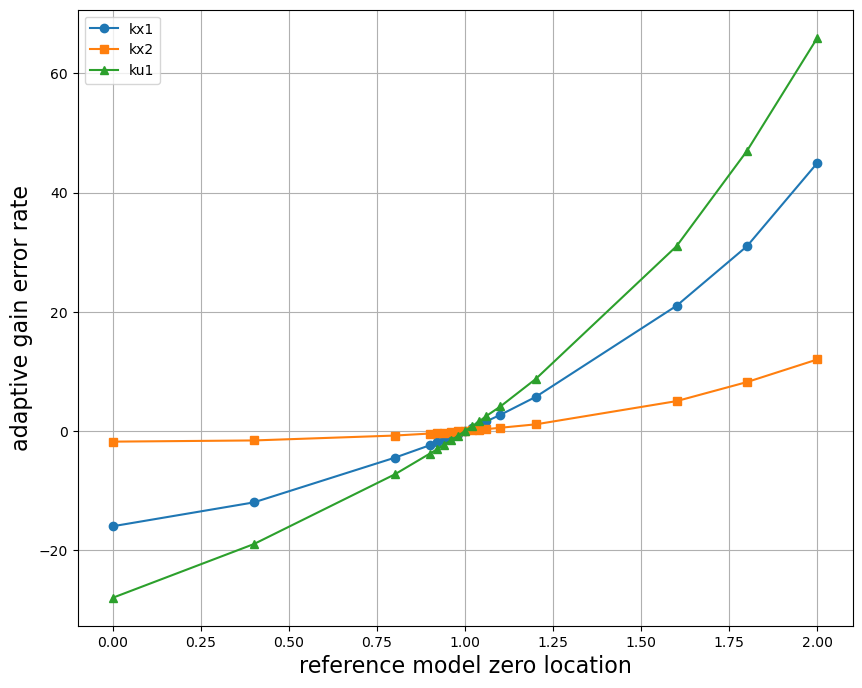

In [27]:
import matplotlib.pyplot as plt


# グラフのサイズ設定
plt.figure(figsize=(10, 8))

# 3つの系列をループしてプロット
# marker='o'などを指定することで、データ点の位置をわかりやすくしています
markers = ['o', 's', '^']  # 丸、四角、三角のマーカーを使用
for i, y_data in enumerate(km):
    if i < 2:
        plt.plot(Bf, y_data, marker=markers[i], label=f'kx{i+1}')
    else:
        plt.plot(Bf, y_data, marker=markers[i], label="ku1")

# 軸ラベルとタイトルの設定
plt.xlabel('reference model zero location',fontsize=16)
plt.ylabel('adaptive gain error rate',fontsize=16)
#plt.title('Line Plot of km vs Bf')

# グリッド（目盛線）を表示
plt.grid(True)

# 凡例を表示
plt.legend()

# グラフを表示
plt.show()

In [10]:
dp(sp.Dict(maindict))

{Am: (Matrix([
[{a_m}_{11}, {a_m}_{12}],
[{a_m}_{21}, {a_m}_{22}]]), Matrix([
[0, {a_m}_{12}],
[1, {a_m}_{22}]]), [[0.0, -24.0], [1.0, -10.0]], [[0.0, -40.0], [1.0, -12.0]]), Ap: (Matrix([
[{a_p}_{11}, {a_p}_{12}],
[{a_p}_{21}, {a_p}_{22}]]), Matrix([
[0, {a_p}_{12}],
[1, {a_p}_{22}]]), [[0.0, 7.5], [1.0, 0.5]], [[0.0, 7.5], [1.0, 0.5]]), Bm: (Matrix([
[{b_m}_{11}],
[{b_m}_{21}]]), Matrix([
[{b_m}_{11}],
[{b_m}_{21}]]), [[2], [1]], [[1.1], [1.0]]), Bp: (Matrix([
[{b_p}_{11}],
[{b_p}_{21}]]), Matrix([
[{b_p}_{11}],
[{b_p}_{21}]]), [[1.0], [1.0]], [[1.0], [1.0]]), Cm: (Matrix([[{c_m}_{11}, {c_m}_{12}]]), Matrix([[0, 1]]), Matrix([[0, 1]]), Matrix([[0, 1]])), Cp: (Matrix([[{c_p}_{11}, {c_p}_{12}]]), Matrix([[0, 1]]), Matrix([[0, 1]]), Matrix([[0, 1]])), Dm: (Matrix([[{d_m}_{11}]]), Matrix([[0]]), Matrix([[0]]), Matrix([[0]])), Dp: (Matrix([[{d_p}_{11}]]), Matrix([[0]]), Matrix([[0]]), Matrix([[0]])), kxku: (Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_u}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}

In [ ]:
#pre =  #sp.parse_expr("Dict(Tuple(Symbol('Dm'), Tuple(ImmutableDenseMatrix([[Integer(0)]]), ImmutableDenseMatrix([[Integer(0)]]))), Tuple(Symbol('Dp'), Tuple(ImmutableDenseMatrix([[Integer(0)]]), ImmutableDenseMatrix([[Integer(0)]]))), Tuple(Symbol('Bm'), Tuple(ImmutableDenseMatrix([[Symbol('{b_{m}}_{1}')], [Symbol('{b_{m}}_{2}')], [Symbol('{b_{m}}_{3}')]]), ImmutableDenseMatrix([[Symbol('{b_{m}}_{1}')], [Symbol('{b_{m}}_{2}')], [Symbol('{b_{m}}_{3}')]]))), Tuple(Symbol('Bp'), Tuple(ImmutableDenseMatrix([[Symbol('{b_{p}}_{1}')], [Symbol('{b_{p}}_{2}')], [Symbol('{b_{p}}_{3}')]]), ImmutableDenseMatrix([[Symbol('{b_{p}}_{1}')], [Symbol('{b_{p}}_{2}')], [Symbol('{b_{p}}_{3}')]]))), Tuple(Symbol('Cm'), Tuple(ImmutableDenseMatrix([[Symbol('{c_{m}}_{1}'), Symbol('{c_{m}}_{2}'), Symbol('{c_{m}}_{3}')]]), ImmutableDenseMatrix([[Integer(0), Integer(0), Integer(1)]]))), Tuple(Symbol('Cp'), Tuple(ImmutableDenseMatrix([[Symbol('{c_{p}}_{1}'), Symbol('{c_{p}}_{2}'), Symbol('{c_{p}}_{3}')]]), ImmutableDenseMatrix([[Integer(0), Integer(0), Integer(1)]]))), Tuple(Symbol('Am'), Tuple(ImmutableDenseMatrix([[Symbol('{a_{m}}_{1}'), Symbol('{a_{m}}_{2}'), Symbol('{a_{m}}_{3}')], [Symbol('{a_{m}}_{4}'), Symbol('{a_{m}}_{5}'), Symbol('{a_{m}}_{6}')], [Symbol('{a_{m}}_{7}'), Symbol('{a_{m}}_{8}'), Symbol('{a_{m}}_{9}')]]), ImmutableDenseMatrix([[Integer(0), Integer(0), Symbol('{a_{m}}_{3}')], [Integer(1), Integer(0), Symbol('{a_{m}}_{6}')], [Integer(0), Integer(1), Symbol('{a_{m}}_{9}')]]))), Tuple(Symbol('Ap'), Tuple(ImmutableDenseMatrix([[Symbol('{a_{p}}_{1}'), Symbol('{a_{p}}_{2}'), Symbol('{a_{p}}_{3}')], [Symbol('{a_{p}}_{4}'), Symbol('{a_{p}}_{5}'), Symbol('{a_{p}}_{6}')], [Symbol('{a_{p}}_{7}'), Symbol('{a_{p}}_{8}'), Symbol('{a_{p}}_{9}')]]), ImmutableDenseMatrix([[Integer(0), Integer(0), Symbol('{a_{p}}_{3}')], [Integer(1), Integer(0), Symbol('{a_{p}}_{6}')], [Integer(0), Integer(1), Symbol('{a_{p}}_{9}')]]))), Tuple(Symbol('cgtans'), Tuple(ImmutableDenseMatrix([[Add(Mul(Symbol('{a_{m}}_{3}'), Symbol('{b_{p}}_{2}')), Mul(Integer(-1), Symbol('{a_{m}}_{6}'), Symbol('{b_{p}}_{1}'))), Add(Mul(Symbol('{a_{m}}_{3}'), Symbol('{b_{p}}_{3}')), Mul(Integer(-1), Symbol('{a_{m}}_{9}'), Symbol('{b_{p}}_{1}'))), Symbol('{b_{p}}_{1}'), Integer(0)], [Add(Mul(Symbol('{a_{m}}_{3}'), Symbol('{b_{p}}_{3}')), Mul(Integer(-1), Symbol('{a_{m}}_{9}'), Symbol('{b_{p}}_{1}'))), Add(Mul(Symbol('{a_{m}}_{6}'), Symbol('{b_{p}}_{3}')), Mul(Integer(-1), Symbol('{a_{m}}_{9}'), Symbol('{b_{p}}_{2}')), Symbol('{b_{p}}_{1}')), Symbol('{b_{p}}_{2}'), Integer(0)], [Symbol('{b_{p}}_{1}'), Symbol('{b_{p}}_{2}'), Symbol('{b_{p}}_{3}'), Integer(0)], [Add(Mul(Symbol('{b_{m}}_{1}'), Symbol('{b_{p}}_{2}')), Mul(Integer(-1), Symbol('{b_{m}}_{2}'), Symbol('{b_{p}}_{1}'))), Add(Mul(Symbol('{b_{m}}_{1}'), Symbol('{b_{p}}_{3}')), Mul(Integer(-1), Symbol('{b_{m}}_{3}'), Symbol('{b_{p}}_{1}'))), Integer(0), Symbol('{b_{p}}_{1}')]]), ImmutableDenseMatrix([[Symbol('{k_{x}}_{1}')], [Symbol('{k_{x}}_{2}')], [Symbol('{k_{x}}_{3}')], [Symbol('{k_{u}}_{1}')]]), ImmutableDenseMatrix([[Add(Symbol('{a_{m}}_{3}'), Mul(Integer(-1), Symbol('{a_{p}}_{3}')))], [Add(Symbol('{a_{m}}_{6}'), Mul(Integer(-1), Symbol('{a_{p}}_{6}')))], [Add(Symbol('{a_{m}}_{9}'), Mul(Integer(-1), Symbol('{a_{p}}_{9}')))], [Symbol('{b_{m}}_{1}')]]))), Tuple(Symbol('cgteqs'), ImmutableDenseMatrix([[Add(Mul(Symbol('{a_{m}}_{3}'), Add(Mul(Symbol('{b_{p}}_{2}'), Symbol('{k_{x}}_{1}')), Mul(Symbol('{b_{p}}_{3}'), Symbol('{k_{x}}_{2}')), Integer(-1))), Mul(Integer(-1), Symbol('{a_{m}}_{6}'), Symbol('{b_{p}}_{1}'), Symbol('{k_{x}}_{1}')), Mul(Integer(-1), Symbol('{a_{m}}_{9}'), Symbol('{b_{p}}_{1}'), Symbol('{k_{x}}_{2}')), Symbol('{a_{p}}_{3}'), Mul(Symbol('{b_{p}}_{1}'), Symbol('{k_{x}}_{3}')))], [Add(Mul(Symbol('{a_{m}}_{3}'), Symbol('{b_{p}}_{3}'), Symbol('{k_{x}}_{1}')), Mul(Symbol('{a_{m}}_{6}'), Symbol('{b_{p}}_{3}'), Symbol('{k_{x}}_{2}')), Mul(Integer(-1), Symbol('{a_{m}}_{6}')), Mul(Integer(-1), Symbol('{a_{m}}_{9}'), Symbol('{b_{p}}_{1}'), Symbol('{k_{x}}_{1}')), Mul(Integer(-1), Symbol('{a_{m}}_{9}'), Symbol('{b_{p}}_{2}'), Symbol('{k_{x}}_{2}')), Symbol('{a_{p}}_{6}'), Mul(Symbol('{b_{p}}_{1}'), Symbol('{k_{x}}_{2}')), Mul(Symbol('{b_{p}}_{2}'), Symbol('{k_{x}}_{3}')))], [Add(Mul(Integer(-1), Symbol('{a_{m}}_{9}')), Symbol('{a_{p}}_{9}'), Mul(Symbol('{b_{p}}_{1}'), Symbol('{k_{x}}_{1}')), Mul(Symbol('{b_{p}}_{2}'), Symbol('{k_{x}}_{2}')), Mul(Symbol('{b_{p}}_{3}'), Symbol('{k_{x}}_{3}')))], [Add(Mul(Symbol('{b_{m}}_{1}'), Add(Mul(Symbol('{b_{p}}_{2}'), Symbol('{k_{x}}_{1}')), Mul(Symbol('{b_{p}}_{3}'), Symbol('{k_{x}}_{2}')), Integer(-1))), Mul(Integer(-1), Symbol('{b_{m}}_{2}'), Symbol('{b_{p}}_{1}'), Symbol('{k_{x}}_{1}')), Mul(Integer(-1), Symbol('{b_{m}}_{3}'), Symbol('{b_{p}}_{1}'), Symbol('{k_{x}}_{2}')), Mul(Symbol('{b_{p}}_{1}'), Symbol('{k_{u}}_{1}')))]])))")

for i in range(refcount):
    cgtw = eqdict["cgtans"].subs(makePDict([("Am", 2+i), ("Ap", 2), ("Bm", 2+i), ("Bp", 2), ("Cm", 2+i), ("Cp", 2)], maindict))
    ks.addparam(maindict, {"kxkut": np.array(cgtw[0].inv()*cgtw[2], dtype=np.float64)})

#simudict["kxkut"] = np.array(cgtarray, dtype=np.float64)
#paramdict["kxkut"] = np.array([*kxku], dtype=np.float64)
display(sp.Dict(maindict))

{Am: (Matrix([
[{a_m}_{11}, {a_m}_{12}],
[{a_m}_{21}, {a_m}_{22}]]), Matrix([
[0, {a_m}_{12}],
[1, {a_m}_{22}]]), [[0.0, -24.0], [1.0, -10.0]], [[0.0, -40.0], [1.0, -12.0]]), Ap: (Matrix([
[{a_p}_{11}, {a_p}_{12}],
[{a_p}_{21}, {a_p}_{22}]]), Matrix([
[0, {a_p}_{12}],
[1, {a_p}_{22}]]), [[0.0, 7.5], [1.0, 0.5]], [[0.0, 7.5], [1.0, 0.5]]), Bm: (Matrix([
[{b_m}_{11}],
[{b_m}_{21}]]), Matrix([
[{b_m}_{11}],
[{b_m}_{21}]]), [[2], [1]], [[1.1], [1.0]]), Bp: (Matrix([
[{b_p}_{11}],
[{b_p}_{21}]]), Matrix([
[{b_p}_{11}],
[{b_p}_{21}]]), [[1.0], [1.0]], [[1.0], [1.0]]), Cm: (Matrix([[{c_m}_{11}, {c_m}_{12}]]), Matrix([[0, 1]]), Matrix([[0, 1]]), Matrix([[0, 1]])), Cp: (Matrix([[{c_p}_{11}, {c_p}_{12}]]), Matrix([[0, 1]]), Matrix([[0, 1]]), Matrix([[0, 1]])), Dm: (Matrix([[{d_m}_{11}]]), Matrix([[0]]), Matrix([[0]]), Matrix([[0]])), Dp: (Matrix([[{d_p}_{11}]]), Matrix([[0]]), Matrix([[0]]), Matrix([[0]])), kxku: (Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_u}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}

In [12]:
#simudict = { "Ap": maindict["Ap"][2], "Bp": maindict["Bp"][2], "Cp": maindict["Cp"][2], "Dp": maindict["Dp"][2], "Cpdiag": np.eye(3),  "Cmdiag": np.eye(3), }
#simudict = {}

for i in range(refcount):
    for k in maindict.keys():
        if k == "kxku":
            continue
        try:
            simudict[k +str(i+1)] = maindict[k][i+2]
        except Exception:
            print("Exception:", k)
        #simudict[k] = maindict[k][i+2]
simudict = simudict | { "Cpdiag": np.eye(dims[0]),  "Cmdiag": np.eye(dims[1]),}
print(simudict)
simudict = {v: np.array(simudict[v], dtype=np.float64) for v in simudict.keys()}
simudict = simudict | { "run_label": str(simudict)}
sc.io.savemat("mparams.mat", simudict, do_compression=False)


{'p_dim': np.int8(2), 'r_dim': np.int8(2), 'K0_e': 0, 'K0_x': array([], dtype=float64), 'K0_u': 0, 'sig_e': 0, 'sig_u': 0, 'kpg_e': 0, 'kpg_u': 0, 'P0': array([[1000.,    0.,    0.,    0.],
       [   0., 1000.,    0.,    0.],
       [   0.,    0., 1000.,    0.],
       [   0.,    0.,    0., 1000.]]), 'theta0': array([[0.],
       [0.],
       [0.],
       [0.]]), 'lambda': 0.98, 'Ts': 0.01, 'T_end': 50, 'Ge': 10.0, 'Gu': 10.0, 'Gx': array([[1000,    0],
       [   0, 1000]]), 'sig_x': array([[0, 0],
       [0, 0]]), 'kpg_x': array([[0., 0.],
       [0., 0.]]), 'sigset': [(0.01, 1, 0), (5, 1, 2), (50, 5, 4), (100, 10, 5)], 'sigfreq': [0.01, 5, 50, 100], 'sigamp': [1, 1, 5, 10], 'sigphs': [0, 2, 4, 5], 'signormcoef': np.float64(0.058823529411764705), 'Dm1': Matrix([[0]]), 'Dp1': Matrix([[0]]), 'Bm1': [[2], [1]], 'Bp1': [[1.0], [1.0]], 'Cm1': Matrix([[0, 1]]), 'Cp1': Matrix([[0, 1]]), 'kxkut1': [[1.4], [-11.9], [0.6]], 'Am1': [[0.0, -24.0], [1.0, -10.0]], 'Ap1': [[0.0, 7.5], [1.0, 0.5]],

In [ ]:
def get_result(filename, valname, latestcount):
    mat_contents = sc.io.loadmat(filename)
    # 保存した変数名 'data_log' を指定して取得
    data = mat_contents[valname]
    # スライスで後ろから2つ取得
    latests = data[-latestcount:]
    for kd in latests:
        print(kd)
        ks.addparam(maindict, {"kxku": sp.Matrix(np.array([*kd[:(pdim+1)]]).flatten())})

In [ ]:
get_result('history.mat', 'data_log', refcount)
display(sp.Dict(maindict))

cgtdlist = []; kxudlist = []
for i in range(refcount):
    cgtd = {}; kxud = {}
    for k in maindict.keys():
        #print(k)
        if k == "kxkut":# "kxku"とした場合にはCGT値で計算 kxkutとした場合にはシミュレーション値
            cgtd = cgtd | makepairdict(maindict[k][0], maindict[k][2+i])
        elif k == "kxku":
            try:
                kxud = kxud | makepairdict(maindict[k][0], maindict[k][2+i])
            except Exception:
                print("error: nodata")
                kxud = kxud | makepairdict(maindict[k][0], maindict["kxkut"][2+i])
                #display(kxud)
        else:
            cgtd = cgtd | makepairdict(maindict[k][0], maindict[k][2+i])
            kxud = kxud | makepairdict(maindict[k][0], maindict[k][2+i])
    #dd[sp.symbols("{k_x}_{11}")] = maindict["kxkut"][2+i][0,0]
    cgtdlist.append(cgtd); kxudlist.append(kxud)

def estimate(paramdicts : list):
    ests = eqdict["estans"]
    ikj = [ests.subs(d) for d in paramdicts]
    ssd = sp.Tuple(
        sp.Matrix(np.vstack([np.array(k[0], dtype=np.float64) for k in ikj])),
        sp.Matrix(np.vstack([np.array(k[2], dtype=np.float64) for k in ikj])) )
    return ssd

def estimate2(paramdicts : list):
    ests = eqdict["estans"]
    ikj = [ests.subs(d) for d in paramdicts]
    ds = []
    for i in range(len(ikj) - 1):
        ds.append(sp.Tuple(ikj[i][0] - ikj[i+1][0], ikj[i][2] - ikj[i+1][2]))
    ssd = sp.Tuple(
        sp.Matrix(np.vstack([np.array(k[0][:, (k[0].shape[0]-1):], dtype=np.float64) for k in ds])),
        sp.Matrix(np.vstack([np.array(k[1], dtype=np.float64) for k in ds])) )
    dp(ssd[0], "divestmat")
    cond = np.linalg.cond(np.array(ssd[0], np.float64))
    estmat = np.linalg.pinv(np.array(ssd[0], dtype=np.float64))
    bps = sp.Matrix(estmat@ssd[1])
    bpdict = makepairdict(ests[1][pdim:, :], bps)
    pdicts = [bpdict | d for d in paramdicts]
    seqs = ests[0][:-1, :] @ ests[1] - ests[2][:-1, :]
    apss = ests[1][:pdim, :]
    asym = []; qes = []
    ty = sp.Dict(sp.solve(seqs, apss))
    for k in ty.keys():
        asym.append(k); qes.append(ty[k])
    ujm= sp.Tuple(sp.Matrix(asym), sp.Matrix(qes))
    apanss = [sp.Matrix(ujm[1].evalf(subs=d)) for d in pdicts]
    apg = (apanss[0] + apanss[1])/2;
    estval = sp.Matrix([*apg,*bps]).reshape(2*pdim, 1)
    return estval, cond


def est_by_pinv(cgtdatas, simdatas):
    est1 = np.linalg.pinv(np.array(cgtdatas[0], dtype=np.float64))
    est2 = np.linalg.pinv(np.array(simdatas[0], dtype=np.float64))
    print("cond1:", np.linalg.cond(np.array(cgtdatas[0], dtype=np.float64)), np.linalg.cond(np.array(simdatas[0], dtype=np.float64)))
    return (sp.Matrix(est1@cgtdatas[1]), sp.Matrix(est2@simdatas[1])), (np.linalg.cond(np.array(cgtdatas[0], dtype=np.float64)), np.linalg.cond(np.array(simdatas[0], dtype=np.float64)))

edt = est_by_pinv(estimate(cgtdlist), estimate(kxudlist))
eqdict["est_by_stack"] = sp.Tuple(*(edt[0]))
eqdict["est_by_stack_cond"] = sp.Tuple(*(edt[1]))

cgtest2 = estimate2(cgtdlist); kxuest2 = estimate2(kxudlist)
eqdict["est_by_div"] = sp.Tuple(cgtest2[0] , kxuest2[0])
eqdict["est_by_div_cond"] = sp.Tuple(cgtest2[1] , kxuest2[1])


def calc_err_rate(est_tuple):
    r = np.array(est_tuple[0], dtype=np.float64); m = np.array(est_tuple[1], dtype=np.float64)
    ans = 100*(m - r) / m; dp(ans)
    return ans

ks.addparam(eqdict, {"est_by_stack": calc_err_rate(eqdict["est_by_stack"])})
ks.addparam(eqdict, {"est_by_div": calc_err_rate(eqdict["est_by_div"])})
"""
dp(eqdict["est_by_stack"], "est_by_stack"); dp(eqdict["est_by_div"], "est_by_div")
dp(eqdict["est_by_stack_cond"], "est_by_stack_cond"); dp(eqdict["est_by_div_cond"], "est_by_div_cond")
"""

[array([[1.84427738]]) array([[-12.87067442]]) array([[0.99902937]])
 array([[31.73409871]]) array([[8.15692792]]) array([[46.91608381]])
 array(["{'p_dim': array(2.), 'r_dim': array(2.), 'K0_e': array(0.), 'K0_x': array([], dtype=float64), 'K0_u': array(0.), 'sig_e': array(0.), 'sig_u': array(0.), 'kpg_e': array(0.), 'kpg_u': array(0.), 'P0': array([[1000.,    0.,    0.,    0.],\n       [   0., 1000.,    0.,    0.],\n       [   0.,    0., 1000.,    0.],\n       [   0.,    0.,    0., 1000.]]), 'theta0': array([[0.],\n       [0.],\n       [0.],\n       [0.]]), 'lambda': array(0.98), 'Ts': array(0.01), 'T_end': array(50.), 'Ge': array(10.), 'Gu': array(10.), 'Gx': array([[1000.,    0.],\n       [   0., 1000.]]), 'sig_x': array([[0., 0.],\n       [0., 0.]]), 'kpg_x': array([[0., 0.],\n       [0., 0.]]), 'sigset': array([[1.e-02, 1.e+00, 0.e+00],\n       [5.e+00, 1.e+00, 2.e+00],\n       [5.e+01, 5.e+00, 4.e+00],\n       [1.e+02, 1.e+01, 5.e+00]]), 'sigfreq': array([1.e-02, 5.e+00, 5.e+01,

{Am: (Matrix([
[{a_m}_{11}, {a_m}_{12}],
[{a_m}_{21}, {a_m}_{22}]]), Matrix([
[0, {a_m}_{12}],
[1, {a_m}_{22}]]), [[0.0, -24.0], [1.0, -10.0]], [[0.0, -40.0], [1.0, -12.0]]), Ap: (Matrix([
[{a_p}_{11}, {a_p}_{12}],
[{a_p}_{21}, {a_p}_{22}]]), Matrix([
[0, {a_p}_{12}],
[1, {a_p}_{22}]]), [[0.0, 7.5], [1.0, 0.5]], [[0.0, 7.5], [1.0, 0.5]]), Bm: (Matrix([
[{b_m}_{11}],
[{b_m}_{21}]]), Matrix([
[{b_m}_{11}],
[{b_m}_{21}]]), [[2], [1]], [[1.1], [1.0]]), Bp: (Matrix([
[{b_p}_{11}],
[{b_p}_{21}]]), Matrix([
[{b_p}_{11}],
[{b_p}_{21}]]), [[1.0], [1.0]], [[1.0], [1.0]]), Cm: (Matrix([[{c_m}_{11}, {c_m}_{12}]]), Matrix([[0, 1]]), Matrix([[0, 1]]), Matrix([[0, 1]])), Cp: (Matrix([[{c_p}_{11}, {c_p}_{12}]]), Matrix([[0, 1]]), Matrix([[0, 1]]), Matrix([[0, 1]])), Dm: (Matrix([[{d_m}_{11}]]), Matrix([[0]]), Matrix([[0]]), Matrix([[0]])), Dp: (Matrix([[{d_p}_{11}]]), Matrix([[0]]), Matrix([[0]]), Matrix([[0]])), kxku: (Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_u}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}

cond1: 359.42904458881225 295.87833541341143


'divestmat'

Matrix([
[  1.32413793103448, 14.6758620689655],
[ 0.193103448275862, 1.80689655172414],
[-0.572413793103448, 1.47241379310345]])

'divestmat'

Matrix([
[ -5.70857399430983,  38.1002243780541],
[-0.214794656661105, 0.557516649574669],
[ 0.217698083955588,  1.42357552145084]])

array([[ 226.31077137],
       [ 109.13706224],
       [ 275.44228318],
       [-197.81176005]])

array([[  67.22942191],
       [-152.83422448],
       [ 298.64926378],
       [-189.28448653]])

'\ndp(eqdict["est_by_stack"], "est_by_stack"); dp(eqdict["est_by_div"], "est_by_div")\ndp(eqdict["est_by_stack_cond"], "est_by_stack_cond"); dp(eqdict["est_by_div_cond"], "est_by_div_cond")\n'

In [15]:
dp(eqdict["estans"])

(Matrix([
[1, 0, -{a_m}_{22}*{k_x}_{11} + {k_x}_{12}, {a_m}_{12}*{k_x}_{11}],
[0, 1,                          {k_x}_{11},            {k_x}_{12}],
[0, 0, -{b_m}_{21}*{k_x}_{11} + {k_u}_{11}, {b_m}_{11}*{k_x}_{11}]]), Matrix([
[{a_p}_{12}],
[{a_p}_{22}],
[{b_p}_{11}],
[{b_p}_{21}]]), Matrix([
[{a_m}_{12}],
[{a_m}_{22}],
[{b_m}_{11}]]))

In [16]:
#info
#dp(sp.Tuple(*_pzk[0][0]), "refmodel pzk", pmode=5); dp( sp.Tuple(*_pzk[0][1]), "plant pzk", pmode=5)
#display(sp.Tuple("Am", *Amps)); display(sp.Tuple("Ap", *Apps))
#ct.bode(ss_am, wrap_phase=True); ct.bode(ss_ap, wrap_phase=True)
dp(sp.Dict(maindict)); dp(sp.Dict(eqdict))

#display(sp.Tuple(*ikj))
dp(eqdict["est_by_stack"], "est_by_stack"); dp(eqdict["est_by_div"], "est_by_div")
dp(eqdict["est_by_stack_cond"], "est_by_stack_cond"); dp(eqdict["est_by_div_cond"], "est_by_div_cond")
#dp(ssp); dp(kuest, "kuest", pmode=5)

{Am: (Matrix([
[{a_m}_{11}, {a_m}_{12}],
[{a_m}_{21}, {a_m}_{22}]]), Matrix([
[0, {a_m}_{12}],
[1, {a_m}_{22}]]), [[0.0, -24.0], [1.0, -10.0]], [[0.0, -40.0], [1.0, -12.0]]), Ap: (Matrix([
[{a_p}_{11}, {a_p}_{12}],
[{a_p}_{21}, {a_p}_{22}]]), Matrix([
[0, {a_p}_{12}],
[1, {a_p}_{22}]]), [[0.0, 7.5], [1.0, 0.5]], [[0.0, 7.5], [1.0, 0.5]]), Bm: (Matrix([
[{b_m}_{11}],
[{b_m}_{21}]]), Matrix([
[{b_m}_{11}],
[{b_m}_{21}]]), [[2], [1]], [[1.1], [1.0]]), Bp: (Matrix([
[{b_p}_{11}],
[{b_p}_{21}]]), Matrix([
[{b_p}_{11}],
[{b_p}_{21}]]), [[1.0], [1.0]], [[1.0], [1.0]]), Cm: (Matrix([[{c_m}_{11}, {c_m}_{12}]]), Matrix([[0, 1]]), Matrix([[0, 1]]), Matrix([[0, 1]])), Cp: (Matrix([[{c_p}_{11}, {c_p}_{12}]]), Matrix([[0, 1]]), Matrix([[0, 1]]), Matrix([[0, 1]])), Dm: (Matrix([[{d_m}_{11}]]), Matrix([[0]]), Matrix([[0]]), Matrix([[0]])), Dp: (Matrix([[{d_p}_{11}]]), Matrix([[0]]), Matrix([[0]]), Matrix([[0]])), kxku: (Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_u}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}

{KAS: (Matrix([
[0, {a_p}_{12}, {b_p}_{11}],
[1, {a_p}_{22}, {b_p}_{21}],
[0,          1,          0]]), Matrix([
[{s_a}_{11}, {s_a}_{12}, {s_b}_{11}],
[{s_a}_{21}, {s_a}_{22}, {s_b}_{21}],
[{k_x}_{11}, {k_x}_{12}, {k_u}_{11}]]), Matrix([
[{s_a}_{12}, {a_m}_{12}*{s_a}_{11} + {a_m}_{22}*{s_a}_{12}, {b_m}_{11}*{s_a}_{11} + {b_m}_{21}*{s_a}_{12}],
[{s_a}_{22}, {a_m}_{12}*{s_a}_{21} + {a_m}_{22}*{s_a}_{22}, {b_m}_{11}*{s_a}_{21} + {b_m}_{21}*{s_a}_{22}],
[         0,                                             1,                                             0]])), cgtans: (Matrix([
[{a_m}_{12}*{b_p}_{21} - {a_m}_{22}*{b_p}_{11}, {b_p}_{11},          0],
[                                   {b_p}_{11}, {b_p}_{21},          0],
[{b_m}_{11}*{b_p}_{21} - {b_m}_{21}*{b_p}_{11},          0, {b_p}_{11}]]), Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_u}_{11}]]), Matrix([
[{a_m}_{12} - {a_p}_{12}],
[{a_m}_{22} - {a_p}_{22}],
[             {b_m}_{11}]])), cgteqs: (Matrix([
[{a_m}_{12}*{b_p}_{21}*{k_x}_{1

'est_by_stack'

(Matrix([
[              7.5],
[0.499999999999991],
[              1.0],
[0.999999999999999]]), Matrix([
[ -5.93773588633459],
[  -5.4722183887953],
[-0.569988022208071],
[ 0.335782576163393]]), [[226.310771370968], [109.137062238301], [275.44228317748], [-197.811760046]])

'est_by_div'

(Matrix([
[7.5],
[0.5],
[1.0],
[1.0]]), Matrix([
[  22.8863829623654],
[ 0.197758037315778],
[-0.503399801717097],
[ 0.345680479449415]]), [[67.2294219128768], [-152.834224482925], [298.649263783776], [-189.284486527199]])

'est_by_stack_cond'

(359.429044588812, 295.878335413411)

'est_by_div_cond'

(21.2998840898669, 86.5677300468475)

In [17]:

def scientific_format(val):
    try:
        # Pythonの書式指定で指数表記にする (例: 1.23e-05)
        val = float(val)
    except Exception:
        return val
    
    # 0の場合はそのまま0
    if val == 0:
        return sp.Symbol("0")
    
    # 【ここがポイント】
    # 絶対値が 10^-3 (0.001) から 10^4 (10000) の範囲なら「そのまま」表示
    if 1e-1 <= abs(val) < 1e2:
        # {:.4g} は有効数字4桁で、不要な0を省略する形式
        # 固定小数点がいい場合は {:.4f} にしてください
        return sp.Symbol(f"{val:.4g}")
    
    else:
        # それ以外（極端に小さい/大きい）は指数表記
        s = "{:.3e}".format(val)
        base, exponent = s.split('e')
        return sp.Symbol(fr"{base} \times 10^{{{int(exponent)}}}")

display(sp.Tuple(maindict["kxku"][0], sp.Matrix(maindict["kxkut"][2]), sp.Matrix(maindict["kxku"][2])))

def printkxku():
    samat1 = sp.Matrix([[maindict["kxku"][0], sp.Matrix(maindict["kxkut"][2]), sp.Matrix(maindict["kxku"][2])]])
    samat2 = sp.Matrix([[maindict["kxku"][0], sp.Matrix(maindict["kxkut"][3]), sp.Matrix(maindict["kxku"][3])]])
    samat3 = sp.Matrix([ samat1, samat2 ])
    erp = sp.Matrix(100*(np.array(samat3[:,1] - samat3[:,2])/ np.array(samat3[:,1])))
    sm4 = sp.Matrix([[samat3, erp]])
    return sm4.applyfunc(scientific_format)
sm4a = printkxku()
dp(sm4a, "kxkus"); print(sp.latex(sm4a))

def printest():
    estsyms = sp.Matrix( [ [maindict["Ap"][0][:, -1]], [maindict["Bp"][0][:, -1]] ] ); dp(estsyms, "estsyms")
    estvec_by_div = sp.Matrix([[estsyms.reshape(pdim*2, 1),eqdict["est_by_div"][0], eqdict["est_by_div"][1], sp.Matrix(eqdict["est_by_div"][2])]]); dp(estvec_by_div)
    estvec_by_stack = sp.Matrix([[estsyms.reshape(pdim*2, 1),eqdict["est_by_stack"][0], eqdict["est_by_stack"][1], sp.Matrix(eqdict["est_by_stack"][2])]]); dp(estvec_by_stack)
    estvev_conn = sp.Matrix([[estsyms.reshape(pdim*2, 1), eqdict["est_by_div"][0], eqdict["est_by_stack"][1], sp.Matrix(eqdict["est_by_stack"][2]), eqdict["est_by_div"][1], sp.Matrix(eqdict["est_by_div"][2])]])
    return estvec_by_div.applyfunc(scientific_format), estvec_by_stack.applyfunc(scientific_format), estvev_conn.applyfunc(scientific_format)
esd, ess, ecc = printest()
dp(esd); print(sp.latex(esd)); dp(ess); print(sp.latex(ess)); dp(ecc); print(sp.latex(ecc))
# ------------

(Matrix([
[{k_x}_{11}],
[{k_x}_{12}],
[{k_u}_{11}]]), Matrix([
[  1.4],
[-11.9],
[  0.6]]), Matrix([
[ 1.84427738197562],
[-12.8706744228346],
[0.999029369914978]]))

'kxkus'

Matrix([
[{k_x}_{11},    1.4,  1.844, -31.73],
[{k_x}_{12},  -11.9, -12.87, -8.157],
[{k_u}_{11},    0.6,  0.999,  -66.5],
[{k_x}_{11},  1.207,  2.059, -70.61],
[{k_x}_{12}, -13.71, -13.43,  2.033],
[{k_u}_{11}, 0.9793, 0.9961, -1.717]])

\left[\begin{matrix}{k_x}_{11} & 1.4 & 1.844 & -31.73\\{k_x}_{12} & -11.9 & -12.87 & -8.157\\{k_u}_{11} & 0.6 & 0.999 & -66.5\\{k_x}_{11} & 1.207 & 2.059 & -70.61\\{k_x}_{12} & -13.71 & -13.43 & 2.033\\{k_u}_{11} & 0.9793 & 0.9961 & -1.717\end{matrix}\right]


'estsyms'

...

\left[\begin{matrix}{a_p}_{12} & 7.5 & 22.89 & 67.23\\{a_p}_{22} & 0.5 & 0.1978 & -1.528 \times 10^{2}\\{b_p}_{11} & 1 & -0.5034 & 2.986 \times 10^{2}\\{b_p}_{21} & 1 & 0.3457 & -1.893 \times 10^{2}\end{matrix}\right]


Matrix([
[{a_p}_{12}, 7.5, -5.938,  2.263 \times 10^{2}],
[{a_p}_{22}, 0.5, -5.472,  1.091 \times 10^{2}],
[{b_p}_{11},   1,  -0.57,  2.754 \times 10^{2}],
[{b_p}_{21},   1, 0.3358, -1.978 \times 10^{2}]])

\left[\begin{matrix}{a_p}_{12} & 7.5 & -5.938 & 2.263 \times 10^{2}\\{a_p}_{22} & 0.5 & -5.472 & 1.091 \times 10^{2}\\{b_p}_{11} & 1 & -0.57 & 2.754 \times 10^{2}\\{b_p}_{21} & 1 & 0.3358 & -1.978 \times 10^{2}\end{matrix}\right]


Matrix([
[{a_p}_{12}, 7.5, -5.938,  2.263 \times 10^{2},   22.89,                67.23],
[{a_p}_{22}, 0.5, -5.472,  1.091 \times 10^{2},  0.1978, -1.528 \times 10^{2}],
[{b_p}_{11},   1,  -0.57,  2.754 \times 10^{2}, -0.5034,  2.986 \times 10^{2}],
[{b_p}_{21},   1, 0.3358, -1.978 \times 10^{2},  0.3457, -1.893 \times 10^{2}]])

\left[\begin{matrix}{a_p}_{12} & 7.5 & -5.938 & 2.263 \times 10^{2} & 22.89 & 67.23\\{a_p}_{22} & 0.5 & -5.472 & 1.091 \times 10^{2} & 0.1978 & -1.528 \times 10^{2}\\{b_p}_{11} & 1 & -0.57 & 2.754 \times 10^{2} & -0.5034 & 2.986 \times 10^{2}\\{b_p}_{21} & 1 & 0.3358 & -1.978 \times 10^{2} & 0.3457 & -1.893 \times 10^{2}\end{matrix}\right]


In [18]:
estsyms = sp.Matrix( [ [maindict["Ap"][0][:, -1]], [maindict["Bp"][0][:, -1]] ] )
dp(ee := eqdict["est_by_div"][1]); print(type(ee), ee.shape)
dp(sp.Matrix([[estsyms.reshape(pdim*2, 1),eqdict["est_by_div"][0], eqdict["est_by_div"][1], sp.Matrix(eqdict["est_by_div"][2])]]))
dp(ee := eqdict["est_by_div"][2]); print(type(ee), ee.shape)

Matrix([
[  22.8863829623654],
[ 0.197758037315778],
[-0.503399801717097],
[ 0.345680479449415]])

<class 'sympy.matrices.immutable.ImmutableDenseMatrix'> (4, 1)


Matrix([
[{a_p}_{12}, 7.5,   22.8863829623654,  67.2294219128768],
[{a_p}_{22}, 0.5,  0.197758037315778, -152.834224482925],
[{b_p}_{11}, 1.0, -0.503399801717097,  298.649263783776],
[{b_p}_{21}, 1.0,  0.345680479449415, -189.284486527199]])

[[67.2294219128768], [-152.834224482925], [298.649263783776], [-189.284486527199]]

<class 'sympy.tensor.array.dense_ndim_array.ImmutableDenseNDimArray'> (4, 1)


In [19]:

def getAs(am12, am22, bm11, bm21, kx11, kx12, ku11):
    As = np.array([[1, 0, -1*am22*kx11 + kx12, am12*kx11],
                [0, 1, kx11, kx12],
                [0, 0, -1*bm21*kx11 + ku11, bm11*kx11]])
    ys = np.array([[am12], [am22], [bm11]])
    return As, ys

def getys(am12, am22, bm11, bm21, kx11, kx12, ku11, bp11, bp21):
    ap12 = -1*((-1*am22*kx11 + kx12)*bp11 + (am12*kx11)*bp21) + am12
    ap22 = -1*(kx11*bp11 + kx12*bp21) + am22
    return np.array([[ap12], [ap22]], dtype=np.float64)

Am1, ym1 = getAs(-108, -21, 3.5, 5, 0.64456, -11.09634, 3.33327)
Am2, ym2 = getAs(-85, -18, 3.5, 5, 0.638194, -9.09177, 3.33335)
AA = np.vstack((Am1, Am2)); yy = np.vstack([ym1, ym2])
display(sp.Tuple(AA, yy))
dp(ans1 := np.linalg.pinv(AA)@yy)
AB = (Am1 - Am2)[:, 2:]; yb = ym1 - ym2
display(sp.Tuple(AB, yb))
dp(ans2b := np.linalg.pinv(AB)@yb)

ty1 = getys(-108, -21, 3.5, 5, 0.64456, -11.09634, 3.33327, float(*ans2b[0]), float(*ans2b[1]))
ty2 = getys(-85, -18, 3.5, 5, 0.638194, -9.09177, 3.33335, *ans2b[0], *ans2b[1])
dp(sp.Tuple(ty1, ty2))

([[1.0, 0.0, 2.43942, -69.61248], [0.0, 1.0, 0.64456, -11.09634], [0.0, 0.0, 0.11047, 2.25596], [1.0, 0.0, 2.395722, -54.24649], [0.0, 1.0, 0.638194, -9.09177], [0.0, 0.0, 0.14238, 2.233679]], [[-108.0], [-21.0], [3.5], [-85.0], [-18.0], [3.5]])

array([[-6.16433623],
       [-5.03649845],
       [ 1.05346354],
       [ 1.49981042]])

([[0.0436979999999991, -15.36599], [0.00636599999999998, -2.00457], [-0.0319099999999999, 0.022281]], [[-23.0], [-3.0], [0.0]])

array([[1.04707279],
       [1.49979173]])

([[-6.15002840926716], [-5.03270225794825]], [[-6.15005816628056], [-5.0324741031913]])

In [20]:
"""
# 対角正準形の場合のCGT解
kx = []; dictype = 0; n_m = 2
for j in range(n_m):
    tb = 0
    for mu in range(n_m):
        tb += (sd("Bp")[dictype][mu, 0]*sd("Cp")[dictype][0, mu])/(sd("Am")[dictype][j, j]-sd("Ap")[dictype][mu, mu])
    #kx.append(ppdict[sp.symbols("Cm")][dictype][0, j] / tb)
    kx.append(1 / tb)
kxp = sp.Matrix(kx)
with sp.evaluate(False):
    cparamdict = {k: round(np.float64(v), 3) for k, v in paramdict.items()}
    kxpp = kxp.subs(cparamdict)
dp(sp.Tuple(kxp, kxpp, kxpp.doit().evalf(5)), "kx", pmode=5)
"""


"""matd = [np.array(m, dtype=np.complex128) for m in Apps]
matb = [np.array(m, dtype=np.complex128) for m in Amps]
(Ap, Bp, Cp, Dp) = matd
(Am, Bm, Cm, Dm) = matb"""

'matd = [np.array(m, dtype=np.complex128) for m in Apps]\nmatb = [np.array(m, dtype=np.complex128) for m in Amps]\n(Ap, Bp, Cp, Dp) = matd\n(Am, Bm, Cm, Dm) = matb'

In [21]:
filename = 'history.mat'; valname = 'data_log'
mat_contents = sc.io.loadmat(filename)
# 保存した変数名 'data_log' を指定して取得
data = mat_contents[valname]
# スライスで後ろから2つ取得
latests = data[-2:]
for kd in latests:
    print(kd)
print
-2.499998073744877	0.499999202063561

SyntaxError: invalid syntax (1647890221.py, line 10)

In [ ]:
np.float64(kd[0][0])

C:\Users\kawan\AppData\Local\Temp\ipykernel_38980\553343541.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  np.float64(kd[0][0])


np.float64(-2.4999980737448766)